# network_v1: Minimal Pulse-Echo Distance Classifier (Ideal Signals)

Top-down prototype using `snntorch` with:
- Gaussian pulse (no carrier)
- Delayed, attenuated echo
- Fixed time-delay bank
- Hidden LIF coincidence layer
- Output LIF distance classifier

This version intentionally uses **no noise and no jitter**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import snntorch as snn

torch.manual_seed(7)
np.random.seed(7)

# Global settings
DT = 1e-4  # 0.1 ms per step
T_STEPS = 768  # 76.8 ms window to capture echoes out to ~10 m
TIME = np.arange(T_STEPS) * DT
SPEED_OF_SOUND = 343.0  # m/s

DISTANCE_CLASSES_M = np.arange(0.5, 10.5, 0.5)
NUM_CLASSES = len(DISTANCE_CLASSES_M)

PULSE_CENTER_STEP = 35
PULSE_STD_STEPS = 6.0
ECHO_ATTENUATION = 0.55

SAMPLES_PER_CLASS = 40
BATCH_SIZE = 64

DELAY_STEPS = torch.unique(torch.cat((torch.arange(0, 257, 8), torch.arange(272, 673, 16)))).long()
HIDDEN_SIZE = 96
BETA = 0.95
EPOCHS = 60
LR = 1e-3

assert DELAY_STEPS.max().item() < T_STEPS, "Largest delay tap must fit inside time window"

## System Diagram

This schematic shows the current notebook flow from waveform input to distance-class output.

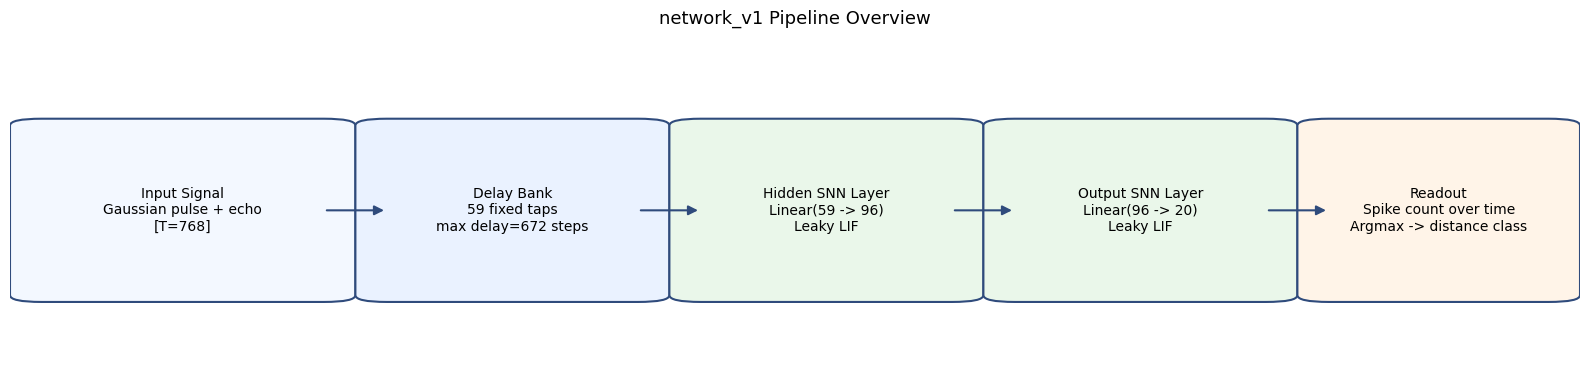

In [2]:
# Pipeline diagram: input -> delay bank -> SNN -> distance class
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def add_box(x, y, w, h, text, fc="#EAF2FF"):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc=fc, ec="#2F4B7C", lw=1.5)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

def add_arrow(x0, y0, x1, y1):
    arr = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=14, lw=1.5, color="#2F4B7C")
    ax.add_patch(arr)

add_box(0.02, 0.25, 0.18, 0.5, f"Input Signal\nGaussian pulse + echo\n[T={T_STEPS}]", fc="#F3F8FF")
add_box(0.24, 0.25, 0.16, 0.5, f"Delay Bank\n{len(DELAY_STEPS)} fixed taps\nmax delay={int(DELAY_STEPS.max().item())} steps", fc="#EAF2FF")
add_box(0.44, 0.25, 0.16, 0.5, f"Hidden SNN Layer\nLinear({len(DELAY_STEPS)} -> {HIDDEN_SIZE})\nLeaky LIF", fc="#EAF7EA")
add_box(0.64, 0.25, 0.16, 0.5, f"Output SNN Layer\nLinear({HIDDEN_SIZE} -> {NUM_CLASSES})\nLeaky LIF", fc="#EAF7EA")
add_box(0.84, 0.25, 0.14, 0.5, "Readout\nSpike count over time\nArgmax -> distance class", fc="#FFF4E8")

add_arrow(0.20, 0.50, 0.24, 0.50)
add_arrow(0.40, 0.50, 0.44, 0.50)
add_arrow(0.60, 0.50, 0.64, 0.50)
add_arrow(0.80, 0.50, 0.84, 0.50)

ax.set_title("network_v1 Pipeline Overview", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


In [3]:
# Added for hardware acceleration (MPS/CUDA), making the code platform-agnostic.
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU (MPS)


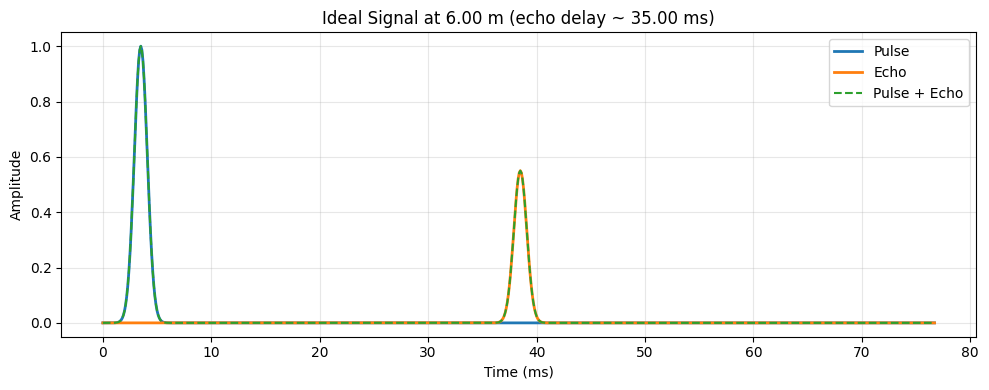

In [12]:
def gaussian_pulse(t_steps, center_step, std_steps, amplitude=1.0):
    idx = np.arange(t_steps)
    return amplitude * np.exp(-0.5 * ((idx - center_step) / std_steps) ** 2)


def make_pulse_echo_signal(distance_m):
    pulse = gaussian_pulse(T_STEPS, PULSE_CENTER_STEP, PULSE_STD_STEPS)

    delay_seconds = 2.0 * distance_m / SPEED_OF_SOUND
    delay_steps = int(round(delay_seconds / DT))

    echo = np.zeros_like(pulse)
    if delay_steps < T_STEPS:
        echo[delay_steps:] = ECHO_ATTENUATION * pulse[: T_STEPS - delay_steps]

    signal = pulse + echo
    return signal.astype(np.float32), pulse.astype(np.float32), echo.astype(np.float32), delay_steps


# Plot one example pulse+echo
example_distance = 6.0
example_signal, example_pulse, example_echo, example_delay_steps = make_pulse_echo_signal(example_distance)
example_delay_ms = example_delay_steps * DT * 1e3

plt.figure(figsize=(10, 4))
plt.plot(TIME * 1e3, example_pulse, label="Pulse", linewidth=2)
plt.plot(TIME * 1e3, example_echo, label="Echo", linewidth=2)
plt.plot(TIME * 1e3, example_signal, label="Pulse + Echo", linestyle="--")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title(f"Ideal Signal at {example_distance:.2f} m (echo delay ~ {example_delay_ms:.2f} ms)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('images_net_1/signal_example.png')
plt.show()

In [5]:
# Build deterministic dataset (no noise, no jitter)
signals = []
labels = []

for class_idx, dist_m in enumerate(DISTANCE_CLASSES_M):
    base_signal, _, _, delay_steps = make_pulse_echo_signal(float(dist_m))
    for _ in range(SAMPLES_PER_CLASS):
        signals.append(base_signal)
        labels.append(class_idx)

X = np.stack(signals)  # [N, T]
y = np.array(labels, dtype=np.int64)

perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")
print(f"Classes (distance m): {DISTANCE_CLASSES_M.tolist()}")
print(f"Chance accuracy: {100.0 / NUM_CLASSES:.1f}%")

Train samples: 640, Test samples: 160
Classes (distance m): [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
Chance accuracy: 5.0%


In [6]:
class DelayBank(nn.Module):
    def __init__(self, delays):
        super().__init__()
        self.register_buffer("delays", delays.clone().long())

    def forward(self, x):
        # x: [T, B, 1]
        t_steps, batch_size, _ = x.shape
        n_delays = self.delays.numel()

        out = torch.zeros(t_steps, batch_size, n_delays, device=x.device, dtype=x.dtype)
        x_flat = x[:, :, 0]

        for i, d in enumerate(self.delays.tolist()):
            if d == 0:
                out[:, :, i] = x_flat
            elif d < t_steps:
                out[d:, :, i] = x_flat[: t_steps - d, :]

        return out


class EchoDistanceSNN(nn.Module):
    def __init__(self, delays, hidden_size, num_classes, beta=0.95):
        super().__init__()
        self.delay_bank = DelayBank(delays)

        self.fc1 = nn.Linear(len(delays), hidden_size)
        self.lif1 = snn.Leaky(beta=beta)

        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x, return_delay=False):
        # x: [T, B, 1]
        delayed = self.delay_bank(x)

        # Clear any module-internal hidden state between forward calls.
        self.lif1.reset_mem()
        self.lif2.reset_mem()

        mem1 = None
        mem2 = None

        spk1_rec = []
        spk2_rec = []

        for t in range(delayed.shape[0]):
            cur1 = self.fc1(delayed[t])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk1_rec.append(spk1)
            spk2_rec.append(spk2)

        spk1_rec = torch.stack(spk1_rec, dim=0)
        spk2_rec = torch.stack(spk2_rec, dim=0)

        if return_delay:
            return spk2_rec, spk1_rec, delayed
        return spk2_rec, spk1_rec

In [7]:
model = EchoDistanceSNN(
    delays=DELAY_STEPS,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    beta=BETA,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Model summary prints
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
num_linear_layers = sum(1 for m in model.modules() if isinstance(m, nn.Linear))
num_lif_layers = sum(1 for m in model.modules() if isinstance(m, snn.Leaky))

print("\n=== Model Summary ===")
print(f"Input time steps: {T_STEPS}")
print(f"Distance classes: {NUM_CLASSES} -> {DISTANCE_CLASSES_M.tolist()}")
print(f"Delay channels: {len(DELAY_STEPS)} (min={int(DELAY_STEPS.min().item())}, max={int(DELAY_STEPS.max().item())} steps)")
print(f"Hidden dimension: {HIDDEN_SIZE}")
print(f"Linear layers: {num_linear_layers}")
print(f"LIF layers: {num_lif_layers}")
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Batch size: {BATCH_SIZE}, epochs: {EPOCHS}, learning rate: {LR}")

train_loss_hist = []
test_loss_hist = []
train_acc_hist = []
test_acc_hist = []

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)  # [T, B, 1]
            spk_out, _ = model(x_time)
            spike_counts = spk_out.sum(dim=0)  # [B, C]

            loss = criterion(spike_counts, y_batch)
            total_loss += loss.item() * y_batch.size(0)

            preds = spike_counts.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)  # [T, B, 1]

        optimizer.zero_grad()
        spk_out, _ = model(x_time)
        spike_counts = spk_out.sum(dim=0)  # [B, C]

        loss = criterion(spike_counts, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)
        preds = spike_counts.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        running_total += y_batch.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    test_loss, test_acc = evaluate(test_loader)

    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc * 100:.1f}% | "
            f"test_loss={test_loss:.4f}, test_acc={test_acc * 100:.1f}%"
        )



=== Model Summary ===
Input time steps: 768
Distance classes: 20 -> [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
Delay channels: 59 (min=0, max=672 steps)
Hidden dimension: 96
Linear layers: 2
LIF layers: 2
Total parameters: 7700
Trainable parameters: 7700
Batch size: 64, epochs: 60, learning rate: 0.001
Epoch 01/60 | train_loss=26.2962, train_acc=4.5% | test_loss=16.1258, test_acc=3.8%
Epoch 05/60 | train_loss=3.8376, train_acc=13.4% | test_loss=3.2520, test_acc=16.9%
Epoch 10/60 | train_loss=1.9640, train_acc=39.4% | test_loss=1.6439, test_acc=54.4%
Epoch 15/60 | train_loss=0.7330, train_acc=82.2% | test_loss=0.7052, test_acc=89.4%
Epoch 20/60 | train_loss=0.3416, train_acc=93.4% | test_loss=0.3728, test_acc=95.0%
Epoch 25/60 | train_loss=0.1591, train_acc=99.5% | test_loss=0.1232, test_acc=100.0%
Epoch 30/60 | train_loss=0.0791, train_acc=99.5% | test_loss=0.0710, test_acc=100.0%
Epoch 35/60 | train_loss=0.0670, train_acc=100

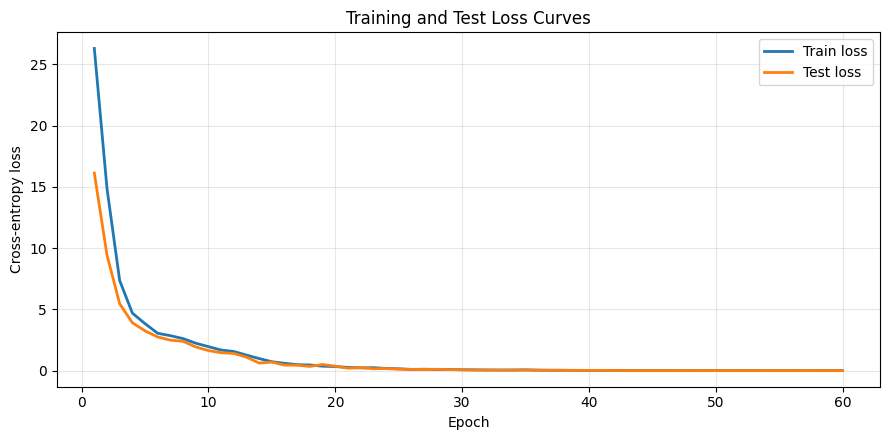

In [13]:
# Loss curves across epochs
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 4.5))
plt.plot(epochs, train_loss_hist, label="Train loss", linewidth=2)
plt.plot(epochs, test_loss_hist, label="Test loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and Test Loss Curves")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('images_net_1/loss_curves.png')
plt.show()


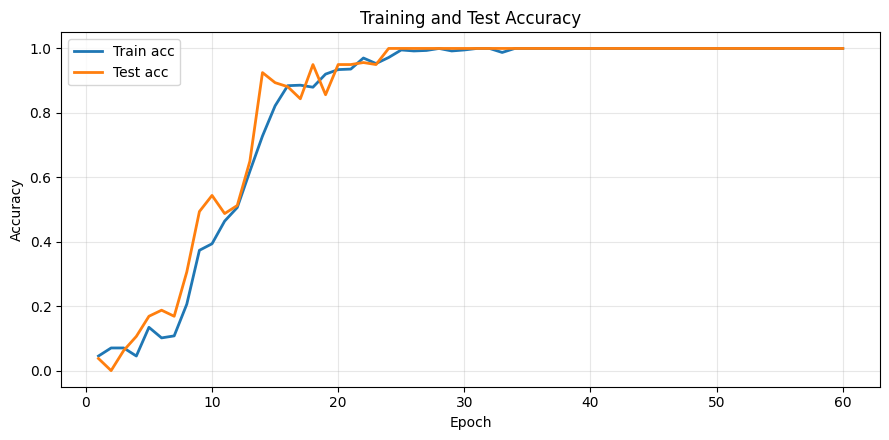

In [14]:
plt.figure(figsize=(9, 4.5))
plt.plot(epochs, train_acc_hist, label="Train acc", linewidth=2)
plt.plot(epochs, test_acc_hist, label="Test acc", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('images_net_1/accuracy.png')
plt.show()

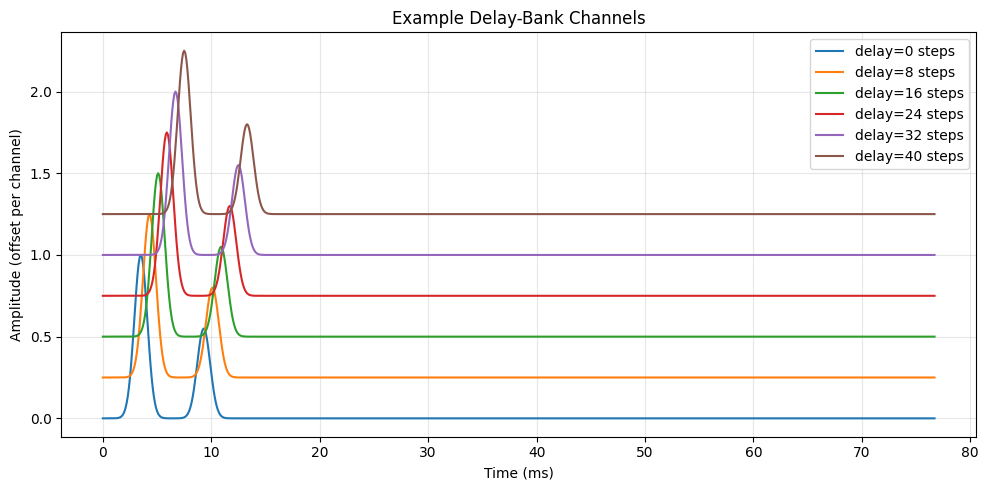

In [9]:
# Delay-bank visualization for one test sample
sample_signal, sample_label = test_ds[0]
sample_input = sample_signal.unsqueeze(0).unsqueeze(-1).permute(1, 0, 2).to(DEVICE)  # [T, 1, 1]

model.eval()
with torch.no_grad():
    sample_spk_out, sample_spk_hidden, sample_delayed = model(sample_input, return_delay=True)

delayed_np = sample_delayed[:, 0, :].cpu().numpy()
n_show = min(6, delayed_np.shape[1])

plt.figure(figsize=(10, 5))
for i in range(n_show):
    plt.plot(TIME * 1e3, delayed_np[:, i] + i * 0.25, label=f"delay={DELAY_STEPS[i].item()} steps")

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (offset per channel)")
plt.title("Example Delay-Bank Channels")
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

In [10]:
# Show a few predictions
num_show = min(10, len(test_ds))
x_show = torch.stack([test_ds[i][0] for i in range(num_show)], dim=0).to(DEVICE)
y_show = torch.tensor([test_ds[i][1] for i in range(num_show)], dtype=torch.long, device=DEVICE)

x_show_time = x_show.unsqueeze(-1).permute(1, 0, 2)

model.eval()
with torch.no_grad():
    spk_show, _ = model(x_show_time)
    spike_counts_show = spk_show.sum(dim=0)
    pred_show = spike_counts_show.argmax(dim=1).cpu().numpy()

print("Sample predictions:")
for i in range(num_show):
    true_idx = int(y_show[i].item())
    pred_idx = int(pred_show[i])
    true_dist = float(DISTANCE_CLASSES_M[true_idx])
    pred_dist = float(DISTANCE_CLASSES_M[pred_idx])
    print(f"  sample {i:02d}: true={true_dist:.2f} m, pred={pred_dist:.2f} m")

Sample predictions:
  sample 00: true=1.00 m, pred=1.00 m
  sample 01: true=2.50 m, pred=2.50 m
  sample 02: true=8.00 m, pred=8.00 m
  sample 03: true=4.00 m, pred=4.00 m
  sample 04: true=7.50 m, pred=7.50 m
  sample 05: true=9.00 m, pred=9.00 m
  sample 06: true=9.50 m, pred=9.50 m
  sample 07: true=7.50 m, pred=7.50 m
  sample 08: true=4.00 m, pred=4.00 m
  sample 09: true=3.00 m, pred=3.00 m


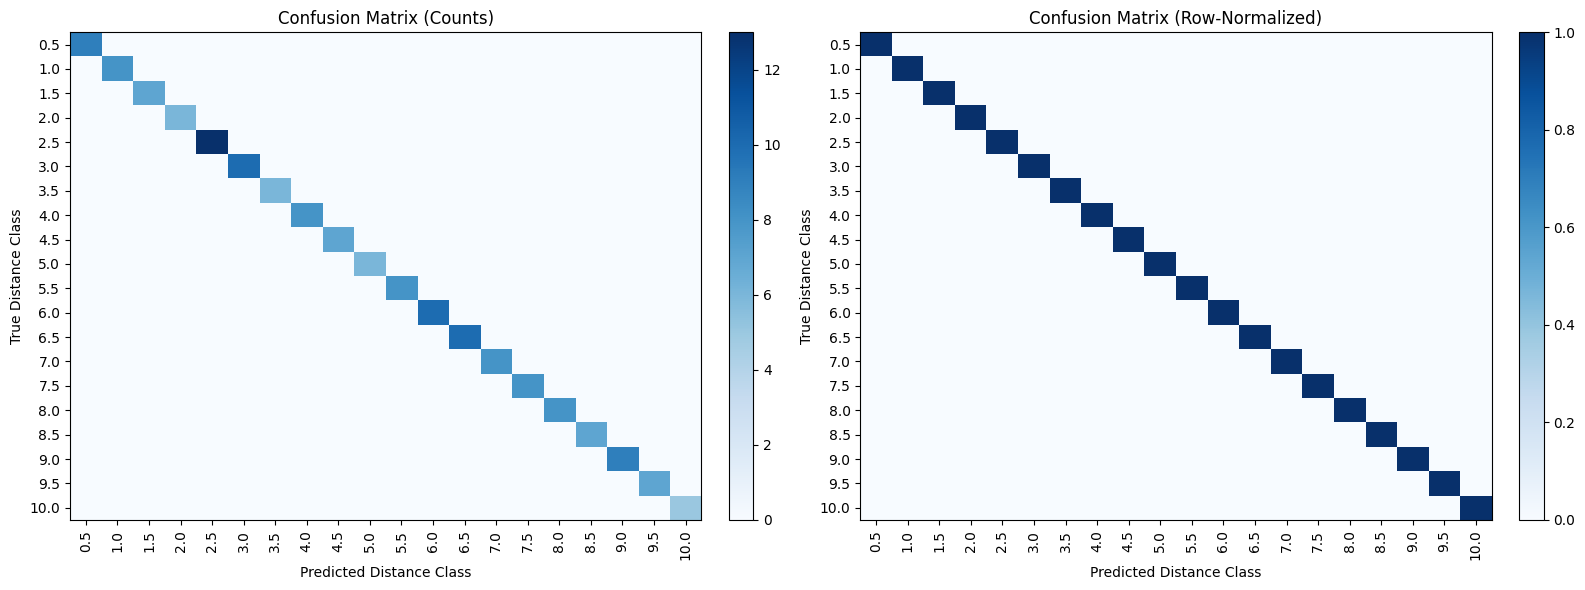

In [11]:
# Confusion matrix heatmap on test set
model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)  # [T, B, 1]
        spk_out, _ = model(x_time)
        spike_counts = spk_out.sum(dim=0)
        preds = spike_counts.argmax(dim=1)

        all_true.append(y_batch.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for t, p in zip(all_true, all_pred):
    cm[t, p] += 1

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Distance Class")
axes[0].set_ylabel("True Distance Class")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0, aspect="auto")
axes[1].set_title("Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted Distance Class")
axes[1].set_ylabel("True Distance Class")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

tick_idx = np.arange(NUM_CLASSES)
tick_labels = [f"{d:.1f}" for d in DISTANCE_CLASSES_M]
for ax in axes:
    ax.set_xticks(tick_idx)
    ax.set_yticks(tick_idx)
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_yticklabels(tick_labels)

plt.tight_layout()
plt.savefig('images_net_1/confusion_matrix.png')
plt.show()